In [1]:
import time
import datetime
import numpy as np
import os,glob
import matplotlib.pyplot as plt
import tensorflow as tf
import random
from common import OUTPUT_DIM_NOTES,SAMPLERATE,INPUT_SHAPE,Q_FACTOR,FRAME_LAG
import soundfile as sf
from fretboardnonredundant import FretBoard
from pathlib import Path
from write_tfrecord_parallel import write_tfrecord_parallel
# input_data_dir = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/input'
# output_data_dir = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/output'

training_dir = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices'
subset = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/training_subset'

input_filepaths = sorted(glob.glob(os.path.join(training_dir, '**', 'input', 'data.tfrecord'), recursive=True))
random.seed(42)
random.shuffle(input_filepaths)


numfiles=10#len(input_filepaths)#500#18000#3426

numfiles=min(numfiles,len(input_filepaths))
print("Loading a fixed set of ",numfiles," files")# Amount to ~1GB on disk without filtering or 312GB with prefiltering
input_filepaths=input_filepaths[:numfiles]
feature_description = {
        "audio_path": tf.io.FixedLenFeature([], tf.string),
        "frame_nr":   tf.io.FixedLenFeature([], tf.int64),
        "output":     tf.io.FixedLenFeature([], tf.string),
    }


print(f'Number of input files: {len(input_filepaths)}')

# tf.py_function that creates a histogram of MIDI note occurrences from the label data in the TFRecord files
def createhist(labels):
    hist = np.zeros((OUTPUT_DIM_NOTES,), dtype=int)
    output_data = labels.numpy()  # Reshape to (num_frames, 89)
    for note in range(OUTPUT_DIM_NOTES):
        if output_data[note] == 1:
            hist[note] += 1
    return hist

# Read the label data from the TFRecord files and create a histogram of MIDI note occurrences
def parse_tfrecord(example_proto):
    parsed = tf.io.parse_single_example(example_proto, feature_description)
    audio = parsed["audio_path"]
    label = tf.io.decode_raw(parsed["output"], tf.int8)
    # hist = tf.py_function(createhist, [label], tf.int32)
    return audio,label

def create_dataset_old(filepaths):
    dataset = tf.data.TFRecordDataset(filepaths)
    dataset = dataset.map(parse_tfrecord, num_parallel_calls=tf.data.AUTOTUNE,use_unbounded_threadpool=True,deterministic=False)
    dataset=dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

def count_midi_notes_old(dataset):
    # hist = np.zeros((OUTPUT_DIM_NOTES,), dtype=int)
    initial_state = tf.zeros((OUTPUT_DIM_NOTES,), dtype=tf.int32)
    
    # 2. Define the reduction function
    # 'old_state' is the current sum, 'next_element' is (features, labels)
    def reduce_fn(old_state, next_element):
        _, labels = next_element
        # Cast labels to int32 to match state and prevent overflow
        return old_state + tf.cast(labels, tf.int32)

    # 3. Perform the reduction
    # This happens in the TF graph and is memory-efficient
    hist = dataset.reduce(initial_state, reduce_fn)
    
    return hist.numpy()
    # Parse the entire batch at once (Vectorized Parsing)
def parse_batch(serialized_batch):
        # Note: feature_description stays the same, but we use parse_example
    parsed = tf.io.parse_example(serialized_batch, feature_description)
        # No need for decode_raw if your data is stored as float/int in the proto, 
        # but if it is bytes, decode_raw works on the whole batch dimension too.
    # audio = tf.io.decode_raw(parsed["audio_path"], tf.string)
    #decode the audio path as string
    audio_path = parsed["audio_path"]
    #print type and value of audio_path
    print("Audio path type:", audio_path.dtype)
    print("Audio path value:", audio_path)
    frame_nr = parsed["frame_nr"]

    label = tf.io.decode_raw(parsed["output"], tf.int8)
    return audio_path,frame_nr, label


def create_dataset(filepaths, batch_size=256):
    # Convert file list to a dataset of strings
    files = tf.data.Dataset.from_tensor_slices(filepaths)
    
    # Read from multiple files in parallel
    dataset = files.interleave(
        tf.data.TFRecordDataset,
        cycle_length=tf.data.AUTOTUNE,
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=False
    )
    
    # Batch the RAW serialized protos FIRST
    dataset = dataset.batch(batch_size)
    

    dataset = dataset.map(parse_batch, num_parallel_calls=tf.data.AUTOTUNE)
    return dataset.prefetch(tf.data.AUTOTUNE)

def count_midi_notes(dataset):
    # Since we are now batched, we sum across the batch dimension first
    initial_state = tf.zeros((OUTPUT_DIM_NOTES,), dtype=tf.int32)
    
    def reduce_fn(old_state, next_element):
        _,_, labels_batch = next_element
        # Sum the batch of labels first, then add to the global state
        batch_sum = tf.reduce_sum(tf.cast(labels_batch, tf.int32), axis=0)
        return old_state + batch_sum

    return dataset.reduce(initial_state, reduce_fn).numpy()

def create_balanced_dataset(filepaths, note_count_max, batch_size=256):
    # 1. Start with the RAW strings (Parallel I/O)
    files = tf.data.Dataset.from_tensor_slices(filepaths)
    dataset = files.interleave(
        tf.data.TFRecordDataset,
        cycle_length=tf.data.AUTOTUNE,
        num_parallel_calls=tf.data.AUTOTUNE,
        deterministic=False
    )
    
    # 2. Vectorized Parsing (The "Turbo" Step)
    # We batch the raw strings, parse them as a block, then unbatch to filter
    dataset = dataset.batch(batch_size)
    dataset = dataset.map(parse_batch, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.unbatch() # Back to individual (audio, label) pairs
    
    # 3. Stateful Filter Logic
    initial_hist = tf.zeros((OUTPUT_DIM_NOTES,), dtype=tf.int32)
    
    def scan_fn(running_hist, element):
        audio,frame_nr, labels = element
        labels_int = tf.cast(labels, tf.int32)
        
        # Identify counts of notes present in this sample (where label == 1)
        # If labels is [0, 1, 1] and hist is [500, 10, 1000], active_counts is [10, 1000]
        active_counts = tf.boolean_mask(running_hist, labels_int > 0)
        
        # "Only keep if the active note with the LEAST count is under the limit"
        # We use tf.reduce_min to find that smallest bin value.
        # If the sample is empty (no notes), we'll default to False to avoid noise.
        has_notes = tf.reduce_any(labels_int > 0)
        min_active_count = tf.reduce_min(active_counts) if has_notes else note_count_max
        
        can_keep = has_notes & (min_active_count < note_count_max)
        
        # Update histogram: only add labels if we decided to keep the sample
        new_hist = tf.where(can_keep, running_hist + labels_int, running_hist)
        
        return new_hist, (audio,frame_nr, labels, can_keep)

    # Apply scan and filter out the 'False' results
    dataset = dataset.scan(initial_state=initial_hist, scan_func=scan_fn)
    dataset = dataset.filter(lambda a,fnr, l, keep: keep)
    dataset = dataset.shuffle(buffer_size=20000, reshuffle_each_iteration=True)
    
    # 4. Final Polish
    # Remove the 'keep' boolean, re-batch for training, and prefetch
    dataset = dataset.map(lambda a,fnr, l, k: (a,fnr, l), num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset

def create_balanced_dataset_poly(filepaths, note_max, poly_max, batch_size=256):
    # 1. High-speed Parallel Parsing
    dataset = tf.data.TFRecordDataset(filepaths, num_parallel_reads=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.map(parse_batch, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.unbatch() 

    # Initial States
    # Note Histogram: counts of individual MIDI notes
    # Poly Histogram: counts of how many samples have X notes (Size is max possible polyphony)
    initial_state = (
        tf.zeros((OUTPUT_DIM_NOTES,), dtype=tf.int32), 
        tf.zeros((OUTPUT_DIM_NOTES,), dtype=tf.int32) 
    )

    def combined_scan_fn(state, element):
        note_hist, poly_hist = state
        audio,frame_nr, labels = element
        labels_int = tf.cast(labels, tf.int32)

        # --- POLYPHONY LEVEL CALCULATION ---
        # How many notes are active in this specific chord?
        num_active = tf.reduce_sum(labels_int)
        
        # Guard: ensure we don't index out of bounds
        poly_idx = tf.minimum(num_active, OUTPUT_DIM_NOTES - 1)
        
        # Check current count for this specific polyphony level
        current_level_count = tf.gather(poly_hist, poly_idx)
        
        # LOGIC: Keep if this polyphony level hasn't reached the uniform 'poly_max'
        keep_poly = current_level_count < poly_max

        # --- NOTE OCCURRENCE LOGIC ---
        active_mask = labels_int > 0
        has_notes = tf.reduce_any(active_mask)
        
        # Keep if the rarest note in this chord is under note_max
        active_counts = tf.boolean_mask(note_hist, active_mask)
        min_note_count = tf.reduce_min(active_counts) if has_notes else note_max
        keep_note = (min_note_count < note_max) if has_notes else True

        # --- FINAL DECISION ---
        can_keep = keep_poly & keep_note & (num_active > 0)

        # --- UPDATE HISTOGRAMS ---
        new_note_hist = tf.where(can_keep, note_hist + labels_int, note_hist)
        
        # Increment the specific polyphony bin using one_hot
        poly_update = tf.one_hot(poly_idx, depth=OUTPUT_DIM_NOTES, dtype=tf.int32)
        new_poly_hist = tf.where(can_keep, poly_hist + poly_update, poly_hist)

        return (new_note_hist, new_poly_hist), (audio,frame_nr, labels, can_keep)

    # Apply scan and filter out the 'False' results
    dataset = dataset.scan(initial_state=initial_state, scan_func=combined_scan_fn)
    dataset = dataset.filter(lambda a,fnr, l, keep: keep)
    dataset = dataset.shuffle(buffer_size=20000, reshuffle_each_iteration=True)
    
    # 4. Final Polish
    # Remove the 'keep' boolean, re-batch for training, and prefetch
    dataset = dataset.map(lambda a,fnr, l, k: (a,fnr, l), num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset

def plot_histogram(hist,size=OUTPUT_DIM_NOTES):
    plt.bar(range(size), hist)
    plt.xlabel('MIDI Note Number')
    plt.ylabel('Count')
    plt.title('Histogram of MIDI Note Occurrences')
    plt.xlim(0, size)  # Limit x-axis to the range of interest
    plt.show()
def filter_notes(hist,note_count_maximum):
    def filter_fn(labels):

        #print shape of hist_part
        #print("Shape of histogram part:", hist_part.shape)
        result=np.ones((1,), dtype=bool)[0]
        # hist=hist+labels

        for note in range(OUTPUT_DIM_NOTES):
            hist[note]+=labels[note]
            # if labels[note] == 1:
            #     if hist[note] >= note_count_maximum: 
            #         result=False
        # assert labels[OUTPUT_DIM_NOTES-1]==0
        
        # Check the minimum count for notes that are present in the current sample
        masks = labels == 1
        #print("Mask for current sample:", masks)
        min_count = np.min(hist[masks]) if np.any(masks) else 0
        # print("Current histogram:", hist)
        # print("Min count for current sample:", min_count)
        # if min_count>0:
        #     print("Minimum count for notes with occurrences:", min_count)
        if min_count >= note_count_maximum:
            #print("Minimum count reached for all notes, stopping filtering: ", min_count)
            result=False
        return result
    filter_function = lambda _,labels: tf.numpy_function(filter_fn, [labels], tf.bool)
    return filter_function

def filter_polyphony(hist,note_count_maximum):
    def filter_fn(labels):

        #print shape of hist_part
        #print("Shape of histogram part:", hist_part.shape)
        result=np.ones((1,), dtype=bool)[0]
        # hist=hist+labels
        num_active_notes=np.sum(labels[:(OUTPUT_DIM_NOTES-1)])
        if num_active_notes>=hist.shape[0]:  
            print("Warning: num_active_notes exceeds histogram size. This should not happen. num_active_notes:", num_active_notes, "histogram size:", hist.shape[0])
            return False        

        if hist[num_active_notes] > note_count_maximum:
            #print("Minimum count reached for all notes, stopping filtering: ", min_count)
            result=False
        else:
            hist[num_active_notes]+=1
        return result
    filter_function = lambda _,labels: tf.numpy_function(filter_fn, [labels], tf.bool)
    return filter_function




def write_tfrecord(
    dataset: tf.data.Dataset,
    output_prefix: str,
    records_per_file: int = 1000,
    num_parallel_calls: int = tf.data.AUTOTUNE,
) -> None:
    """
    Serialise a (audio_path, frame_nr, label) dataset to sharded TFRecord files.

    Fixes vs. original:
      • Writer is always closed (context manager / finally block).
      • New writer is opened only when needed, not when i % N == 0
        (which would skip closing the old writer).
      • record_count tracked explicitly instead of relying on modulo.
    """
    Path(output_prefix).parent.mkdir(parents=True, exist_ok=True)

    serialized_ds = dataset.unbatch().map(
        lambda a, fnr, l: tf.py_function(
            serialize_example, [a, fnr, l], [tf.string, tf.string]
        ),
        num_parallel_calls=num_parallel_calls,
    )

    writer       = None
    file_index   = 0
    record_count = 0

    try:
        for protos in serialized_ds:
            # protos is a list of two tf.string tensors [orig, stretched]
            for proto in protos:
                if writer is None or record_count >= records_per_file:
                    if writer is not None:
                        writer.close()
                    shard_path = f"{output_prefix}_{file_index:05d}.tfrecord"
                    writer      = tf.io.TFRecordWriter(shard_path)
                    file_index += 1
                    record_count = 0

                writer.write(proto.numpy())
                record_count += 1
    finally:
        if writer is not None:
            writer.close()

    print(f"Wrote {file_index} shard(s) to {output_prefix}_*.tfrecord")


#serialize example for a path object, an integer and numpy array
def _int64_feature(value: int) -> tf.train.Feature:
    return tf.train.Feature(int64_list=tf.train.Int64List(value=[value]))

def _path_feature(value: str) -> tf.train.Feature:
    print("Encoding path:", value)
    return tf.train.Feature(bytes_list=tf.train.BytesList(value=[value]))

def _bytes_feature(value: bytes) -> tf.train.Feature:
    return tf.train.Feature(bytes_list=tf.train.BytesList(value=[value]))

loaded_audio_cache = {}
average_proctime=0
average_proctime_count=0
def fast_stretch(data,stretch_factor=0.9):
    datalen=len(data)
    #print(datalen)
    new_indices=np.linspace(0,datalen-1,num=datalen)*stretch_factor

    #print(new_indices)
    return np.interp(new_indices,np.arange(datalen),data)
def filter_to_string(audio_segments,startframe,endframe,output):
    fretboard=FretBoard(Q_FACTOR,SAMPLERATE)

    input=np.zeros((INPUT_SHAPE[0],INPUT_SHAPE[1]),dtype=np.float32)
    for f in range(startframe,endframe):
        f=f-startframe
        audio_segment=audio_segments[f*INPUT_SHAPE[1]:(f+1)*INPUT_SHAPE[1]]
        fretboard.process(audio_segment,input)


    input=input*127
    input=input.astype(np.int8)
    feature = {
        "input":  _bytes_feature(input.tobytes()),
        #"frame_nr": _int64_feature(frame_nr),
        "output": _bytes_feature(output.numpy().tobytes()),
    }
    # print("frame_nr:", frame_nr)
    example = tf.train.Example(features=tf.train.Features(feature=feature))
    return example.SerializeToString()

def serialize_example(audio_path: str,frame_nr: int, output: np.ndarray) -> bytes:
    #print("Serializing example with audio_path:", audio_path, "frame_nr:", frame_nr, "output shape:", output.numpy().shape)
    #print("Types - audio_path:", type(audio_path), "frame_nr:", type(frame_nr), "output:", type(output))
    # Extract the actual value from the EagerTensor
    global average_proctime, average_proctime_count,loaded_audio_cache
    if hasattr(audio_path, 'numpy'):
        #print("Extracting audio path from EagerTensor")
        audio_path = audio_path.numpy()
        #print("Audio path after extraction:", audio_path)
    

    if hasattr(frame_nr, 'numpy'):
        frame_nr = int(frame_nr.numpy()) # Force to native int

    # # check the cachesize. If it is larger than 5GB, clear the cache
    # cache_size = sum(len(v[0]) * v[0].itemsize for v in loaded_audio_cache.values())
    # if cache_size > 5 * 1024 * 1024 * 1024:  # 5GB
    #     print("Clearing audio cache to free up memory. Current cache size: {:.2f} GB".format(cache_size / (1024 * 1024 * 1024)))
    #     loaded_audio_cache.clear()
    # Load the audio path file and run Freboard processing from frame_nr-50 to frame_nr and store result in "input" variable
    # Load the audio file using soundfile
    # Clear cache if it exceed 100 elements
    if len(loaded_audio_cache) > 10:
        #print("Clearing audio cache to free up memory. Current cache size: {} items".format(len(loaded_audio_cache)))
        loaded_audio_cache.clear()
    if audio_path in loaded_audio_cache:
        audio, sr = loaded_audio_cache[audio_path]
    else:
        audio, sr = sf.read(audio_path.decode('utf-8'))  # Decode bytes to string for file reading
        loaded_audio_cache[audio_path] = (audio, sr)
    # Create a Fretboard instance and process the audio segment from frame_nr-5 to frame_nr to get the input features
    # to the neural network. Measure the time taken for processing and print it. If it takes more than 1 second, print a warning.
    # print the average processing time for 100 samples
    # print the keys of the loaded_audio_cache
    # print("Loaded audio cache keys:", list(loaded_audio_cache.keys()))
   # start_time = time.time()

    audioframes=audio.shape[0]//INPUT_SHAPE[1]
   # print("Audio frames: ",audioframes)
    startframe=max(0,frame_nr-FRAME_LAG)
    endframe=min(frame_nr+1,audioframes)
    #print("Start frame:",startframe," end frame:",endframe)
    audio_segments=audio[startframe*INPUT_SHAPE[1]:endframe*INPUT_SHAPE[1]]
   
    example = filter_to_string(audio_segments,startframe,endframe,output)


    
    # add an extraframe, in case stretchval<1.0.
    endframe=min(frame_nr+1,audioframes)
    audio_segments=audio[startframe*INPUT_SHAPE[1]:endframe*INPUT_SHAPE[1]]

    #print(audio_segments.shape)
    stretch_val = np.random.uniform(0.9, 1.1)
    #print("Start frame:",startframe," end frame:",endframe)

    shifted_segments=fast_stretch(audio_segments,stretch_val)
    example_shifted = filter_to_string(shifted_segments,startframe,endframe-1,output)



    return [example,example_shifted]


I0000 00:00:1773827475.100650 1539041 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1773827475.125438 1539041 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773827475.630454 1539041 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Loading a fixed set of  10  files
Number of input files: 10


In [2]:
execute_block = False
if execute_block:
    #print the time when the script started
    print("Script started at:", datetime.datetime.now())
    view_histogram = True
    if view_histogram:
        dataset = create_dataset(input_filepaths)
        print("Dataset created, counting MIDI notes...")
        print("This may take a while...")

        midi_histogram = count_midi_notes(dataset)
        plot_histogram(midi_histogram)

    note_count_maximum = 100000#int(0.1*1e6)#1000000#0.2*10**6
    # Create dataset in which each note is limited to a maximum count of note_count_maximum by filtering out samples with that note until the count is below the maximum

    if view_histogram:
        filtered_dataset=create_balanced_dataset(input_filepaths, note_count_maximum, batch_size=256)
        print("Filtered dataset created, counting MIDI notes again...")
        filtered_midi_histogram = count_midi_notes(filtered_dataset)
        plot_histogram(filtered_midi_histogram)


    # Write the audio and label data of the filtered dataset to new TFRecord files


    #Create output directory if it doesn't exist
    os.makedirs(subset, exist_ok=True)

    output_filepath = os.path.join(subset, 'filtered_data.tfrecord')
    print("Writing filtered dataset to TFRecord:", output_filepath)
    # midi_histogram= np.zeros((OUTPUT_DIM_NOTES,), dtype=int)
    # filtered_dataset = dataset.filter(filter_notes(midi_histogram,note_count_maximum))
    filtered_dataset=create_balanced_dataset(input_filepaths, note_count_maximum, batch_size=256)

    # #get the number of samples in the filtered dataset 
    # num_samples = 0
    # for _ in filtered_dataset:
    #     num_samples += 1
    # print(f"Number of samples in the filtered dataset: {num_samples}")
    # write_tfrecord(filtered_dataset, output_filepath)
    print(f"Filtered dataset written to {output_filepath}")

    #print the time when the script finished
    print("Script finished at:", datetime.datetime.now())


Script started at: 2026-03-18 10:51:16.719240
Audio path type: <dtype: 'string'>
Audio path value: Tensor("ParseExample/ParseExampleV2:0", shape=(None,), dtype=string)
Dataset created, counting MIDI notes...
This may take a while...


W0000 00:00:1773827476.783681 1539041 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
W0000 00:00:1773827476.788940 1539041 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.
I0000 00:00:1773827476.861575 1539041 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 12160 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 5080, pci bus id: 0000:01:00.0, compute capability: 12.0a
I0000 00:00:1773827476.990812 1539213 tf_record_dataset_op.cc:390] TFRecordDataset `buffer_size` is unspecified, default to 262144


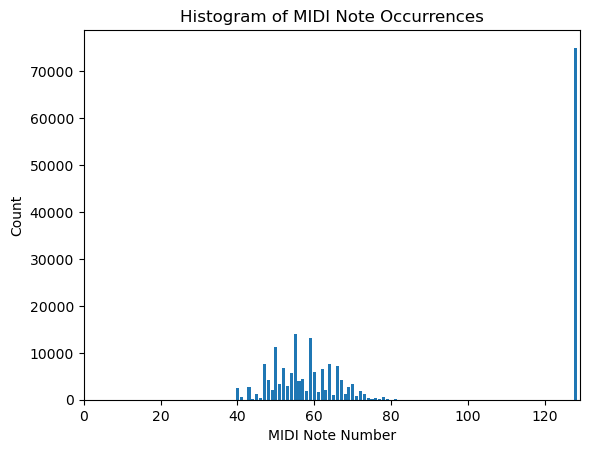

Labels batch (first 5 samples): Tensor("strided_slice_1:0", shape=(None, None), dtype=int8)
Num active batch (first 5 samples): Tensor("strided_slice_2:0", shape=(None,), dtype=int32)
Labels batch shape: (None, None)
Num active batch shape: (None,)
Histogram of concurrent notes in the filtered dataset: [76136 36927  1364 19284  1682  4104  2193    21    26     7     4     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0   

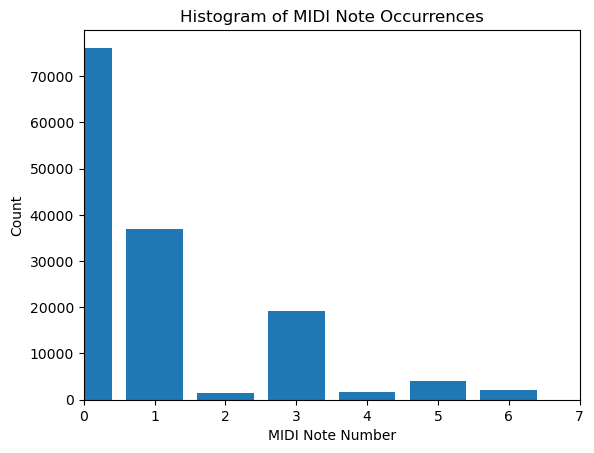

Audio path type: <dtype: 'string'>
Audio path value: Tensor("ParseExample/ParseExampleV2:0", shape=(None,), dtype=string)
Labels batch (first 5 samples): Tensor("strided_slice_1:0", shape=(None, None), dtype=int8)
Num active batch (first 5 samples): Tensor("strided_slice_2:0", shape=(None,), dtype=int32)
Labels batch shape: (None, None)
Num active batch shape: (None,)
Histogram of concurrent notes in the polyphony-filtered dataset: [74434 36927  1364 19284  1682  4104  2193    21    26     7     4     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     

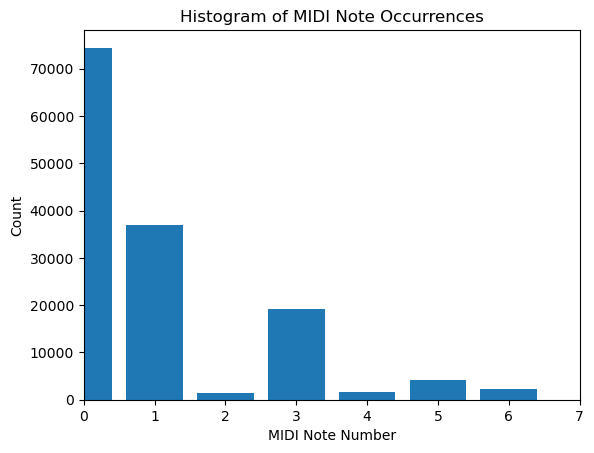

Audio path type: <dtype: 'string'>
Audio path value: Tensor("ParseExample/ParseExampleV2:0", shape=(None,), dtype=string)
Histogram of MIDI notes in the polyphony-filtered dataset: [    0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0  2399   634     0  2672   153  1115   465  7689
  4140  2138 11317  3416  6719  2909  5631 14040  3901  4499  1893 13147
  5972  1637  6476  2130  7565  1051  7235  4236  1293  2764  3292   809
  1782  1247   358   130   352   144   681    82     0   258     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0     0     0     0     0
     0     0     0     0     0     0     0     0 75046]


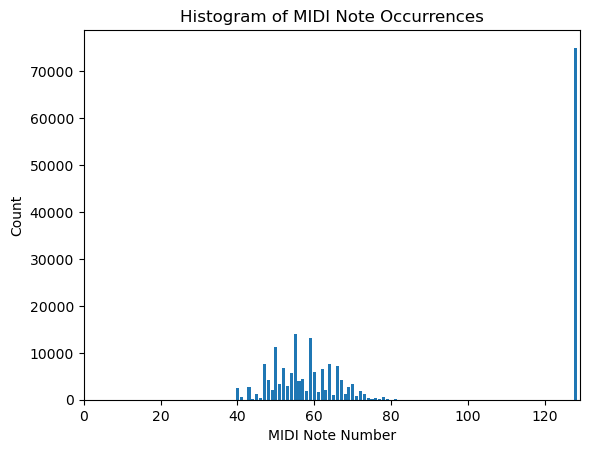

Writing polyphony-filtered dataset to TFRecord: /home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/training_subset/filtered_poly_data
Write parallel using 30 workers
5000 protos queued ...
10000 protos queued ...
15000 protos queued ...
20000 protos queued ...
25000 protos queued ...
30000 protos queued ...
35000 protos queued ...
40000 protos queued ...
45000 protos queued ...
50000 protos queued ...
55000 protos queued ...
60000 protos queued ...
65000 protos queued ...
70000 protos queued ...
75000 protos queued ...
80000 protos queued ...
85000 protos queued ...
90000 protos queued ...
95000 protos queued ...
100000 protos queued ...
105000 protos queued ...
110000 protos queued ...
115000 protos queued ...
120000 protos queued ...
125000 protos queued ...
130000 protos queued ...
135000 protos queued ...
140000 protos queued ...
145000 protos queued ...
150000 protos queued ...
155000 protos queued ...
160000 protos queued ...
165000 protos queued ...


In [3]:
write_block = True
plot_block = True
#print the time when the script started

print("Script started at:", datetime.datetime.now())

# Load the filtered dataset and create a histogram over the number of concurrent notes in the labels
subset = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/training_subset/'

Path(subset).mkdir(parents=True,exist_ok=True)
if plot_block:
    dataset = create_dataset(input_filepaths)
    print("Dataset created, counting MIDI notes...")
    print("This may take a while...")

    midi_histogram = count_midi_notes(dataset)
    plot_histogram(midi_histogram)
def count_concurrent_notes_distribution(dataset, max_polyphony=129, batch_size=256):
    # 1. Ensure the dataset is batched for vectorized math
    # If the input dataset is already batched, this line won't hurt.
    batched_ds = dataset#.batch(batch_size,drop_remainder=True) if not hasattr(dataset, '_batch_size') else dataset

    # State: Histogram of size max_polyphony
    initial_state = tf.zeros((max_polyphony,), dtype=tf.int64)
    
    def reduce_fn(old_state, next_element):
        _,_, labels_batch = next_element # Shape: (batch, OUTPUT_DIM_NOTES)
        active_notes_only = labels_batch[..., :-1]
        # 1. Count active notes for every sample in the batch at once
        # Resulting shape: (batch_size,)
        num_active_batch = tf.reduce_sum(tf.cast(active_notes_only, tf.int32), axis=-1)
        #print labels_batch and num_active_batch for debugging
        print("Labels batch (first 5 samples):", labels_batch[:5])
        print("Num active batch (first 5 samples):", num_active_batch[:5])

        # print shapes
        print("Labels batch shape:", labels_batch.shape)
        print("Num active batch shape:", num_active_batch.shape)
        
        # 2. Clip values to stay within histogram bounds
        num_active_batch = tf.clip_by_value(num_active_batch, 0, max_polyphony - 1)
        
        # 3. Use bincount to create a mini-histogram for the entire batch
        # This is the secret to speed—no loops, no individual one-hots.
        batch_hist = tf.math.bincount(
            num_active_batch, 
            minlength=max_polyphony, 
            maxlength=max_polyphony, 
            dtype=tf.int64
        )
        
        return old_state + batch_hist

    # Perform the reduction on the graph
    hist = batched_ds.reduce(initial_state, reduce_fn)
    return hist.numpy()
note_count_maximum = 2e7
poly_count_maximum = 2e7
# Now run it
if plot_block:
    concurrent_notes_histogram = count_concurrent_notes_distribution(dataset)
    print("Histogram of concurrent notes in the filtered dataset:", concurrent_notes_histogram)
    plot_histogram(concurrent_notes_histogram[:7],7)
    
    filtered_poly_ds=create_balanced_dataset_poly(input_filepaths, note_max=int(note_count_maximum), poly_max=int(poly_count_maximum), batch_size=256)

    polyphony_histogram = count_concurrent_notes_distribution(filtered_poly_ds)
    print("Histogram of concurrent notes in the polyphony-filtered dataset:", polyphony_histogram)
    plot_histogram(polyphony_histogram[:7],7)

filtered_poly_ds=create_balanced_dataset_poly(input_filepaths, note_max=int(note_count_maximum), poly_max=int(poly_count_maximum), batch_size=256)
# if plot_block:
notes_histo=count_midi_notes(filtered_poly_ds)
print("Histogram of MIDI notes in the polyphony-filtered dataset:", notes_histo)
plot_histogram(notes_histo)

# write the values of notes_histo to a csv file in order to create weights for the labels in the loss function during training
import csv




if write_block:
    with open(os.path.join(subset, 'note_histogram.csv'), mode='w', newline='') as csv_file:
        writer = csv.writer(csv_file)
        writer.writerow(['MIDI Note', 'Count'])
        for note, count in enumerate(notes_histo):
            writer.writerow([note, count])
    # write the filtered dataset to a new TFRecord file
    output_filepath_poly = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/training_subset/filtered_poly_data'
    print("Writing polyphony-filtered dataset to TFRecord:", output_filepath_poly)
    write_tfrecord_parallel(filtered_poly_ds, output_filepath_poly)
    print(f"Polyphony-filtered dataset written to {output_filepath_poly}")

#print the time when the script finished
print("Script finished at:", datetime.datetime.now())
# poweroff the machine after processing


# os.system("poweroff")


In [4]:

# #poweroff the machine after processing
# # show a modal window with the message "Processing finished. Do you want to power off the machine?" and two buttons "Yes" and "No". If the user clicks "Yes", poweroff the machine. If the user clicks "No", do nothing.
# # the window should have a countdown timer of 30 seconds, after which it will automatically poweroff the machine if the user has not made a choice. The window should also display the time when the processing finished and the total processing time.
# import tkinter as tk
# from tkinter import messagebox
# import threading
# import time
# def countdown(count):
#     while count > 0:
#         time.sleep(1)
#         count -= 1
#     # If the user has not made a choice after the countdown, poweroff the machine
#     os.system("poweroff")
# def on_closing():
#     if messagebox.askokcancel("Quit", "Processing finished. Do you want to power off the machine?"):
#         os.system("poweroff")
# root = tk.Tk()
# root.protocol("WM_DELETE_WINDOW", on_closing)
# root.title("Processing Finished")
# label = tk.Label(root, text="Processing finished at: {}\nTotal processing time: {:.2f} seconds\nThe machine will automatically power off in 30 seconds.".format(datetime.datetime.now(), (datetime.datetime.now() - datetime.datetime.strptime("2024-06-01 00:00:00", "%Y-%m-%d %H:%M:%S")).total_seconds()))   
# label.pack(padx=20, pady=20)
# # Start the countdown in a separate thread so it doesn't block the GUI
# threading.Thread(target=countdown, args=(30,)).start()
# root.mainloop()


In [ ]:
# import os
# os.system("sleep 10")
# os.system("poweroff")